<a href="https://colab.research.google.com/github/ysn-gachon/AI-Class-202335225-nayeonsu/blob/main/Week6/abalone_Classification_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.csv')
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])

# 나중에 클래스 이름을 확인하고 싶을 때
# print(encoder.classes_)
df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1695 - loss: 2.7701 - val_accuracy: 0.2272 - val_loss: 2.3840
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2156 - loss: 2.2626 - val_accuracy: 0.2870 - val_loss: 2.1874
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2406 - loss: 2.1471 - val_accuracy: 0.2526 - val_loss: 2.1155
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2616 - loss: 2.0875 - val_accuracy: 0.2541 - val_loss: 2.0604
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2597 - loss: 2.0657 - val_accuracy: 0.2407 - val_loss: 2.0435
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2567 - loss: 2.0362 - val_accuracy: 0.2780 - val_loss: 2.0143
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2597 - loss: 2.0225 - val_accuracy: 0.2586 - val_loss: 2.0016
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2754 - loss: 2.0071 - val_accuracy: 0.2735 - val_

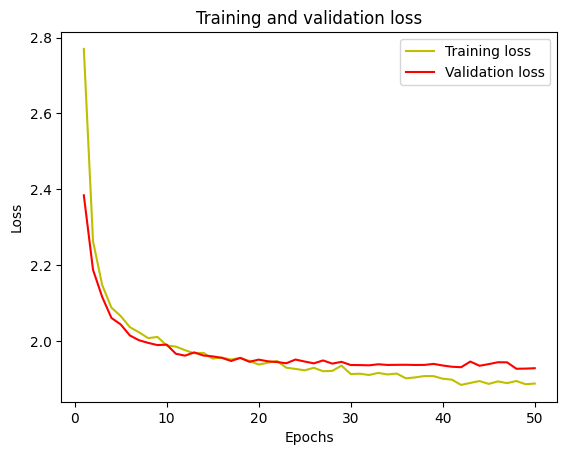

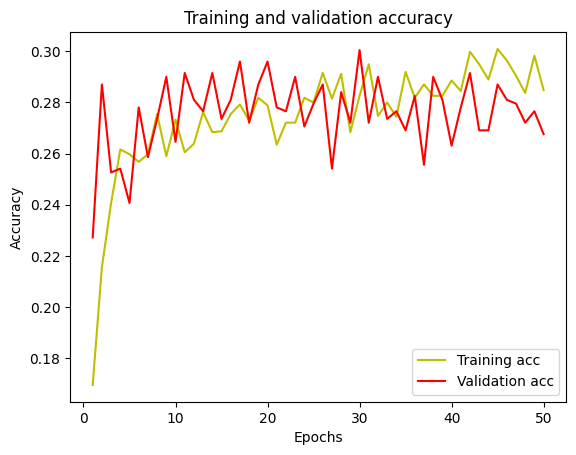

              precision    recall  f1-score   support

           2       0.00      0.00      0.00         5
           3       0.18      0.27      0.21        11
           4       0.29      0.12      0.17        33
           5       0.38      0.57      0.46        47
           6       0.43      0.37      0.40        98
           7       0.38      0.40      0.39       113
           8       0.32      0.40      0.36       127
           9       0.20      0.39      0.26       107
          10       0.25      0.26      0.26        95
          11       0.10      0.05      0.06        66
          12       0.00      0.00      0.00        39
          13       0.20      0.04      0.06        26
          14       0.12      0.06      0.08        18
          15       0.07      0.07      0.07        14
          16       0.00      0.00      0.00        10
          17       0.00      0.00      0.00         5
          18       0.00      0.00      0.00         8
          19       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [4]:
from tensorflow.keras import layers, models
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

X = df.drop('Rings', axis=1)
y = df['Rings']

scaler = StandardScaler()
X = scaler.fit_transform(X)

Y = pd.get_dummies(y).values

from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="softmax")   # 클래스 수 맞춤
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # one-hot이면 categorical_crossentropy
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy'] # Corrected from 'val_acc'
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))